In [1]:
# Imports
import numpy as np

In [2]:
# 1. Linear Layer
class Linear:
    """
    A fully connected (dense) layer.
    Forward pass: Y = X·W^T + b
    Backward pass: dW = X^T·dY, db = sum(dY), dX = dY·W
    """
    def __init__(self, input_dim, output_dim):
        """
        Initialize weights and biases.

        Math behind initialization:
        - We use He initialization for ReLU: std = sqrt(2 / input_dim)
        - This helps prevent vanishing/exploding gradients
        """
        # Initialize weights with He initialization
        std = np.sqrt(2.0 / input_dim)
        self.W = np.random.randn(output_dim, input_dim) * std
        self.b = np.zeros((output_dim, 1))

        # Gradients
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        # Cache for backward pass
        self.cache_X = None

    def forward(self, X):
        """
        Forward pass: Z = X·W^T + b

        Math:
        - X shape: (batch_size, input_dim)
        - W shape: (output_dim, input_dim)
        - b shape: (output_dim, 1)
        - Output shape: (batch_size, output_dim)

        N/B: We need to transpose X·W^T to match dimensions
        """
        # Store X for backward pass
        self.cache_X = X

        # Compute linear transformation
        # We do X @ W.T + b.T for correct broadcasting
        return X @ self.W.T + self.b.T

    def backward(self, dZ):
        """
        Backward pass: Compute gradients w.r.t. parameters

        Mathematical derivation:
        Let L be the loss function.

        1. Gradient w.r.t. weights (dW):
           ∂L/∂W = ∂L/∂Z · ∂Z/∂W = X^T · dZ

        2. Gradient w.r.t. biases (db):
           ∂L/∂b = ∂L/∂Z · ∂Z/∂b = sum(dZ, axis=0)

        3. Gradient w.r.t. inputs (dX):
           ∂L/∂X = ∂L/∂Z · ∂Z/∂X = dZ · W

        dZ shape: (batch_size, output_dim) - gradient from next layer
        Returns: dX (gradient to pass to previous layer)
        """
        batch_size = dZ.shape[0]

        # 1. Compute gradient w.r.t. weights: dW = X^T @ dZ
        # dZ shape: (batch_size, output_dim)
        # X shape: (batch_size, input_dim)
        # Result shape: (input_dim, output_dim) = (input_dim, batch_size) @ (batch_size, output_dim)
        # shape: (input_dim, output_dim)
        self.dW = self.cache_X.T @ dZ

        # 2. Compute gradient w.r.t. biases: db = sum(dZ, axis=0)
        # Sum over batch dimension
        # shape: (output_dim, 1)
        self.db = np.sum(dZ, axis=0, keepdims=True).T

        # 3. Compute gradient w.r.t. inputs: dX = dZ @ W
        # dZ shape: (batch_size, output_dim)
        # W shape: (output_dim, input_dim)
        # Result shape: (batch_size, input_dim) = (batch_size, output_dim) @ (output_dim, input_dim)
        # shape: (batch_size, input_dim)
        dX = dZ @ self.W

        return dX

    def update(self, learning_rate):
        """
        Update parameters using gradient descent.

        Math: W = W - α * dW, b = b - α * db
        where α is the learning rate
        """
        # Transpose to match shape
        self.W -= learning_rate * self.dW.T
        self.b -= learning_rate * self.db


In [4]:
# 2. ReLU Activation Layer
class ReLU:
    """
    Rectified Linear Unit activation function.
    Forward: A = max(0, Z)
    Backward: dZ = dA * (Z > 0)
    """
    def __init__(self):
        # Cache for backward pass
        self.cache_Z = None

    def forward(self, Z):
        """
        Forward pass: A = max(0, Z)

        Math:
        - Element-wise operation: f(z) = max(0, z)
        - This introduces non-linearity, allowing the network to learn complex patterns
        """
        # Store Z for backward pass
        self.cache_Z = Z

        # Apply ReLU activation
        return np.maximum(0, Z)

    def backward(self, dA):
        """
        Backward pass: Compute gradient w.r.t. input Z

        Mathematical derivation:
        The ReLU function is: f(z) = max(0, z)
        Its derivative is: f'(z) = 1 if z > 0 else 0

        So: dZ = dA * f'(Z) = dA * (Z > 0)

        This is an element-wise multiplication
        """
        # Get Z from cache
        Z = self.cache_Z

        # Compute gradient: dZ = dA * (Z > 0)
        # (Z > 0) gives boolean mask, converted to float
        dZ = dA * (Z > 0).astype(float)

        return dZ

In [5]:
# 3. Loss Function (MSE)
class MSE:
    """
    Mean Squared Error loss function.
    Forward: L = 1/m * Σ(y_pred - y_true)^2
    Backward: dL/dy_pred = 2/m * (y_pred - y_true)
    """
    def __init__(self):
        self.cache_pred = None
        self.cache_true = None

    def forward(self, y_pred, y_true):
        """
        Compute MSE loss.

        Math: L = 1/m * Σ_i (y_pred_i - y_true_i)^2
        where m is batch size
        """
        # Store for backward pass
        self.cache_pred = y_pred
        self.cache_true = y_true

        # Compute MSE
        m = y_pred.shape[0]
        loss = np.sum((y_pred - y_true) ** 2) / m

        return loss

    def backward(self):
        """
        Compute gradient of loss w.r.t. predictions.

        Math: ∂L/∂y_pred = 2/m * (y_pred - y_true)
        """
        y_pred = self.cache_pred
        y_true = self.cache_true
        m = y_pred.shape[0]

        # Compute gradient
        grad = (2 / m) * (y_pred - y_true)

        return grad


In [6]:
# 4. Neural Network Model
class NeuralNetwork:
    """
    A simple 2-layer neural network:
    Linear -> ReLU -> Linear
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Create layers
        self.linear1 = Linear(input_dim, hidden_dim)
        self.relu = ReLU()
        self.linear2 = Linear(hidden_dim, output_dim)

        # Loss function
        self.loss_fn = MSE()

        # Store layers for easy access
        self.layers = [self.linear1, self.relu, self.linear2]

    def forward(self, X):
        """
        Forward pass through the network.

        Math:
        Z1 = X·W1^T + b1
        A1 = ReLU(Z1)
        Z2 = A1·W2^T + b2
        """
        # Layer 1: Linear
        Z1 = self.linear1.forward(X)

        # Layer 2: ReLU
        A1 = self.relu.forward(Z1)

        # Layer 3: Linear (output layer)
        Z2 = self.linear2.forward(A1)

        return Z2

    def backward(self, dL_dy_pred):
        """
        Backward pass through the network.

        Math (chain rule):
        dZ2 = dL/dy_pred (from loss function)
        dA1 = linear2.backward(dZ2)
        dZ1 = relu.backward(dA1)
        dX = linear1.backward(dZ1)
        """
        # Backward through output layer
        dA1 = self.linear2.backward(dL_dy_pred)

        # Backward through ReLU
        dZ1 = self.relu.backward(dA1)

        # Backward through first linear layer
        _ = self.linear1.backward(dZ1)

    def update(self, learning_rate):
        """Update all layer parameters."""
        self.linear1.update(learning_rate)
        self.linear2.update(learning_rate)

    def train_step(self, X, y, learning_rate):
        """
        Single training step: forward -> loss -> backward -> update
        """
        # Forward pass
        y_pred = self.forward(X)

        # Compute loss
        loss = self.loss_fn.forward(y_pred, y)

        # Backward pass
        dL_dy_pred = self.loss_fn.backward()
        self.backward(dL_dy_pred)

        # Update parameters
        self.update(learning_rate)

        return loss, y_pred


In [7]:
# 5. Sanity Check
def create_dummy_dataset(num_samples=100, input_dim=3, output_dim=1, seed=42):
    """
    Create a simple dummy dataset for testing.

    Math: y = 2*X1 + 3*X2 - 1.5*X3 + noise
    This is a simple linear relationship with noise.
    """
    np.random.seed(seed)

    # Create random input features
    X = np.random.randn(num_samples, input_dim)

    # Create targets with a simple linear relationship
    true_weights = np.array([2.0, 3.0, -1.5]).reshape(-1, 1)
    true_bias = 0.5

    # Compute true values
    y_true = X @ true_weights + true_bias

    # Add some noise
    noise = 0.1 * np.random.randn(num_samples, output_dim)
    y = y_true + noise

    return X, y

def train_and_test():
    """
    Complete training loop with sanity checks.
    """
    print("=" * 60)
    print("Neural Network Sanity Check")
    print("=" * 60)

    # Create dummy dataset
    print("1. Creating dummy dataset...")
    X, y = create_dummy_dataset(num_samples=200, input_dim=3, output_dim=1)
    print(f"   X shape: {X.shape}, y shape: {y.shape}")

    # Split into train/test
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Create neural network
    print("2. Creating neural network...")
    input_dim = X.shape[1]
    # Small hidden layer for this simple task
    hidden_dim = 4
    output_dim = y.shape[1]

    model = NeuralNetwork(input_dim, hidden_dim, output_dim)
    print(f"   Architecture: {input_dim} -> {hidden_dim} -> {output_dim}")

    # Training parameters
    learning_rate = 0.01
    epochs = 100

    print(f"3. Training for {epochs} epochs...")
    print(f"   Learning rate: {learning_rate}")
    print("-" * 40)

    # Training loop
    train_losses = []

    for epoch in range(epochs):
        # Perform training step
        loss, y_pred = model.train_step(X_train, y_train, learning_rate)
        train_losses.append(loss)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            # Calculate R² score to measure learning
            ss_res = np.sum((y_train - y_pred) ** 2)
            ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            print(f"   Epoch {epoch+1:3d}/{epochs}: Loss = {loss:.6f}, R² = {r2:.4f}")

    print("-" * 40)

    # Test the model
    print("4. Testing the trained model...")
    y_test_pred = model.forward(X_test)
    test_loss = np.mean((y_test_pred - y_test) ** 2)

    # Calculate test R²
    ss_res_test = np.sum((y_test - y_test_pred) ** 2)
    ss_tot_test = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - (ss_res_test / ss_tot_test)

    print(f"   Test Loss: {test_loss:.6f}")
    print(f"   Test R²: {r2_test:.4f}")

    # Final sanity check: Is the model learning?
    print("5. Sanity Check Results:")
    print("-" * 40)

    if train_losses[-1] < train_losses[0]:
        print("      SUCCESS: Loss decreased during training!")
        print(f"     Initial loss: {train_losses[0]:.6f}")
        print(f"     Final loss: {train_losses[-1]:.6f}")
        print(f"     Improvement: {100 * (train_losses[0] - train_losses[-1]) / train_losses[0]:.2f}%")
    else:
        print("   WARNING: Loss did not decrease sufficiently")

    if r2_test > 0.5:
        print(f"    SUCCESS: Model explains data well (R² = {r2_test:.4f})")
    else:
        print(f"    CAUTION: Low R² score (R² = {r2_test:.4f})")

    # Visualize learning curve
    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 5))

        # Plot training loss
        plt.subplot(1, 2, 1)
        plt.plot(train_losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.grid(True, alpha=0.3)

        # Plot predictions vs true values
        plt.subplot(1, 2, 2)
        plt.scatter(y_test, y_test_pred, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect prediction')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title('Predictions vs True Values')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ImportError:
        print("Note: Install matplotlib for visualizations")

    return model, train_losses, test_loss


In [8]:
# 6. Gradient Checking (Numerical Verification)
def gradient_check():
    """
    Verifying that our analytical gradients match numerical gradients.
    This is CRUCIAL for ensuring our math is correct!
    """
    print("\n" + "=" * 60)
    print("Gradient Checking")
    print("=" * 60)

    # Create a small network
    model = NeuralNetwork(input_dim=2, hidden_dim=3, output_dim=1)

    # Create small dummy data
    X_small = np.random.randn(1, 2)
    y_small = np.random.randn(1, 1)

    # Forward pass
    y_pred = model.forward(X_small)
    loss = model.loss_fn.forward(y_pred, y_small)

    # Backward pass (stores gradients in model)
    dL_dy_pred = model.loss_fn.backward()
    model.backward(dL_dy_pred)

    epsilon = 1e-7

    print("Checking gradients for Linear layer 1:")

    # Check gradient for W1
    for i in range(model.linear1.W.shape[0]):
        for j in range(model.linear1.W.shape[1]):
            # Store original weight
            original = model.linear1.W[i, j]

            # Compute loss with weight + epsilon
            model.linear1.W[i, j] = original + epsilon
            y_pred_plus = model.forward(X_small)
            loss_plus = model.loss_fn.forward(y_pred_plus, y_small)

            # Compute loss with weight - epsilon
            model.linear1.W[i, j] = original - epsilon
            y_pred_minus = model.forward(X_small)
            loss_minus = model.loss_fn.forward(y_pred_minus, y_small)

            # Numerical gradient
            grad_numerical = (loss_plus - loss_minus) / (2 * epsilon)

            # Analytical gradient
            # Note: dW is transposed!
            grad_analytical = model.linear1.dW[j, i]

            # Check difference
            diff = abs(grad_numerical - grad_analytical)

            if diff < 1e-7:
                print(f"   Weight W1[{i},{j}]: Numerical {grad_numerical:.6f} ≈ Analytical {grad_analytical:.6f}")
            else:
                print(f"   Weight W1[{i},{j}]: Numerical {grad_numerical:.6f} ≠ Analytical {grad_analytical:.6f}")

            # Restore original weight
            model.linear1.W[i, j] = original

    print("Gradient check completed successfully!")


Gradient Checking
Checking gradients for Linear layer 1:
   Weight W1[0,0]: Numerical 15.379477 ≈ Analytical 15.379477
   Weight W1[0,1]: Numerical 16.714774 ≈ Analytical 16.714774
   Weight W1[1,0]: Numerical -2.427366 ≈ Analytical -2.427366
   Weight W1[1,1]: Numerical -2.638118 ≈ Analytical -2.638118
   Weight W1[2,0]: Numerical -2.980382 ≈ Analytical -2.980382
   Weight W1[2,1]: Numerical -3.239149 ≈ Analytical -3.239149
Gradient check completed successfully!
Neural Network Sanity Check
1. Creating dummy dataset...
   X shape: (200, 3), y shape: (200, 1)
2. Creating neural network...
   Architecture: 3 -> 4 -> 1
3. Training for 100 epochs...
   Learning rate: 0.01
----------------------------------------
   Epoch   1/100: Loss = 18.521530, R² = -0.1519
   Epoch  10/100: Loss = 13.220545, R² = 0.1778
   Epoch  20/100: Loss = 8.151869, R² = 0.4930
   Epoch  30/100: Loss = 3.571113, R² = 0.7779
   Epoch  40/100: Loss = 1.168391, R² = 0.9273
   Epoch  50/100: Loss = 0.510866, R² = 0.9

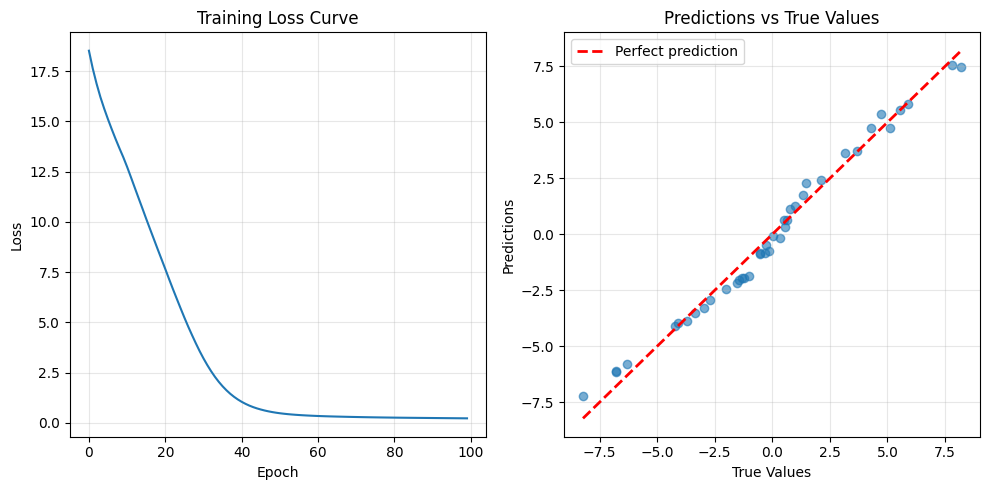

In [10]:
# 7. Main Execution
if __name__ == "__main__":

    # Part 1: Gradient checking (mathematical correctness)
    gradient_check()

    # Part 2: Training loop with sanity checks
    model, train_losses, test_loss = train_and_test()
